In [1]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(series: FourierSeries, terms: int) -> int:
    popcounts = popcount(np.asarray(np.argpartition(series.coeffs, -terms)[-terms:]))
    inv_popcounts = series.signal.number_spins - popcounts
    return np.sum(np.minimum(popcounts, inv_popcounts))


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]

logger.remove()
logger.add(Path("boolean-analysis-complexity.log", level="DEBUG", colorize=True))


2023-02-13 20:32:00.730 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-13 20:32:00.733 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
2023-02-13 20:32:00.787 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


1

In [2]:
%matplotlib inline

In [3]:
class LatticeOptions(NamedTuple):
    lattice: SpinLattice
    use_symmetries: bool
    max_terms: int | None

In [4]:
# lattice_opts = [
#     LatticeOptions(lattice=SquareLattice(width=4, height=4), use_symmetries=True, max_terms=None),
#     LatticeOptions(
#         lattice=SquareLattice(width=4, height=5), use_symmetries=False, max_terms=2**11
#     ),
#     LatticeOptions(
#         lattice=SquareLattice(width=4, height=6), use_symmetries=True, max_terms=2**15
#     ),
#     LatticeOptions(TriangleLattice(width=4, height=4), use_symmetries=True, max_terms=None),
#     LatticeOptions(TriangleLattice(width=4, height=5), use_symmetries=False, max_terms=2**11),
#     LatticeOptions(TriangleLattice(width=4, height=6), use_symmetries=True, max_terms=2**15),
#     LatticeOptions(KagomeLattice(width=2, height=2), use_symmetries=False, max_terms=None),
#     LatticeOptions(KagomeLattice(width=2, height=3), use_symmetries=False, max_terms=None),
#     LatticeOptions(KagomeLattice(width=2, height=4), use_symmetries=True, max_terms=2**16),
# ]
# 

lattice_opts = [
    LatticeOptions(lattice=KagomeLattice(width=2, height=5), use_symmetries=False, max_terms=2 ** (16 + 5 + 5)),
]
name_to_lattice_opt = {lattice.lattice.get_cache_id(): lattice for lattice in lattice_opts}

In [5]:
%matplotlib inline

In [6]:
J2s = [0.0]
signal_kinds = [SignSignalKind()
                #, AmplitudeMedianBinSignalKind()
                ]

In [7]:
all_series: dict[tuple[str, float, str], FourierSeries] = {}

for (lattice_opt, J2, signal_kind) in product(lattice_opts, J2s, signal_kinds):
    lattice, use_symmetries, max_terms = lattice_opt
    print(f"lattice: {lattice.get_cache_id()}, J2: {J2}, signal_kind: {signal_kind.name}")
    system=HeisenbergJ1J2(
                lattice=lattice,
                J1=1,
                J2=J2,
                use_symmetries=use_symmetries,
                spin_inversion=1 if use_symmetries else None,
                ground_state_cache_dir=ground_state_cache_dir,
    )
    print("Finding ground state")
    system.get_eigenstates(1)
    print(f"Finding fourier expansion")
    series = fourier_expand(LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind))
    all_series[lattice.get_cache_id(), J2, signal_kind.name] = series


lattice: KagomeLattice2x5, J2: 0.0, signal_kind: sign


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding ground state
Finding fourier expansion
lattice: KagomeLattice2x5, J2: 0.0, signal_kind: amplitude_median_bin
Finding ground state
Finding fourier expansion


In [24]:
scorers = ["sign_overlap", "accuracy", "f1"]
target_score = 0.8
target_scorer = "f1"

rows = []

for (lattice_name, J2, signal_kind), series in all_series.items():
    lattice, use_symmetries, max_terms = name_to_lattice_opt[lattice_name]

    success, how_many_terms, prediction = series.how_many_terms_to_achieve_score(
        target_score, scorer=target_scorer, max_terms=max_terms, orbitwise=False
    )
    scores = {
        scorer: series.truncate(
            keep_largest_n(how_many_terms)
        ).prediction_score(scorer=scorer, prediction=prediction)[0]
        for scorer in scorers
    }
    rows.append(
        {
            "lattice_name": lattice_name,
            "J2": J2,
            "signal_kind": signal_kind,
            "series": series,
            "success": success,
            "terms": how_many_terms,
            "prediction": prediction,
        }
        | scores
    )
    print(rows[-1])


{'lattice_name': 'SquareLattice4x4', 'J2': 0.0, 'signal_kind': 'sign', 'series': <fast_boolean_analysis.FourierSeries object at 0x1491c76fc070>, 'success': True, 'terms': 1, 'prediction': array([ 0.19638062,  0.19638062, -0.19638062, ..., -0.19638062,
        0.19638062,  0.19638062]), 'sign_overlap': 1.0, 'accuracy': 1.0, 'f1': 1.0}
{'lattice_name': 'SquareLattice4x4', 'J2': 0.0, 'signal_kind': 'amplitude_median_bin', 'series': <fast_boolean_analysis.FourierSeries object at 0x1491c76fc5b0>, 'success': True, 'terms': 34, 'prediction': array([-0.30825806, -0.21340942,  0.02371216, ...,  0.02371216,
       -0.21340942, -0.30825806]), 'sign_overlap': 0.898894897932802, 'accuracy': 0.7291375291375292, 'f1': 0.7722465096601325}
{'lattice_name': 'SquareLattice4x4', 'J2': 0.1, 'signal_kind': 'sign', 'series': <fast_boolean_analysis.FourierSeries object at 0x1491c76b0a30>, 'success': True, 'terms': 1, 'prediction': array([ 0.19638062,  0.19638062, -0.19638062, ..., -0.19638062,
        0.19638

In [55]:
rows[0]

{'lattice_name': 'SquareLattice4x4',
 'J2': 0.0,
 'signal_kind': 'sign',
 'series': <fast_boolean_analysis.FourierSeries at 0x1491c76fc070>,
 'success': True,
 'terms': 1,
 'prediction': array([ 0.19638062,  0.19638062, -0.19638062, ..., -0.19638062,
         0.19638062,  0.19638062]),
 'sign_overlap': 1.0,
 'accuracy': 1.0,
 'f1': 1.0}

In [56]:
# Workaround for a fixed bug
for row in rows:
    series = row['series'].truncate(keep_largest_n(row['terms']))
    prediction = series.predict()
    scores = {
        scorer: series.truncate(
            keep_largest_n(how_many_terms)
        ).prediction_score(scorer=scorer, prediction=prediction)[0]
        for scorer in scorers
    }

    row.update(dict(prediction=prediction) | scores)

In [57]:
series_df = (
    pd.DataFrame(rows)
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["series"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["series"].apply(lambda a: a.signal.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["lattice_name", "J2", "signal_kind"])
)


In [58]:
series_df.drop('series', axis=1).reset_index().to_feather("boolean_analysis-complexity-series.feather")

In [60]:
series_df.query('success == False')

,,,series,success,terms,prediction,sign_overlap,accuracy,f1,hamming_weight,number_spins,mean_hw
lattice_name,J2,signal_kind,,,,,,,,,,


In [107]:
np.log2(series_df.query('lattice_name.str.startswith("Kagome")').groupby('number_spins')['terms'].max())

number_spins
12     5.954196
18    10.336507
24    14.882500
Name: terms, dtype: float64

In [63]:
%matplotlib inline

In [65]:
series_df

series  \
lattice_name     J2  signal_kind                                                               
SquareLattice4x4 0.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
                     amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
                 0.1 sign                  <fast_boolean_analysis.FourierSeries object at...   
                     amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
                 0.2 sign                  <fast_boolean_analysis.FourierSeries object at...   
...                                                                                      ...   
KagomeLattice2x4 0.8 amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
                 0.9 sign                  <fast_boolean_analysis.FourierSeries object at...   
                     amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   
                 1.0 sign                  <fast_boolean_analysis.FourierSeries object at...   
                     amplitude_median_bin  <fast_boolean_analysis.FourierSeries object at...   

                                           success  terms  \
lattice_name     J2  signal_kind                            
SquareLattice4x4 0.0 sign                     True      1   
                     amplitude_median_bin     True     34   
                 0.1 sign                     True      1   
                     amplitude_median_bin     True     40   
                 0.2 sign                     True      1   
...                                            ...    ...   
KagomeLattice2x4 0.8 amplitude_median_bin     True     32   
                 0.9 sign                     True  26322   
                     amplitude_median_bin     True     32   
                 1.0 sign                     True  30205   
                     amplitude_median_bin     True     32   

                                                                                  prediction  \
lattice_name     J2  signal_kind                                                               
SquareLattice4x4 0.0 sign                  [0.196380615234375, 0.196380615234375, -0.1963...   
                     amplitude_median_bin  [-0.33197021484375, -0.189697265625, 0.0, -0.0...   
                 0.1 sign                  [0.196380615234375, 0.196380615234375, -0.1963...   
                     amplitude_median_bin  [-0.36376953125, -0.0909423828125, -0.13641357...   
                 0.2 sign                  [0.196380615234375, 0.196380615234375, -0.1963...   
...                                                                                      ...   
KagomeLattice2x4 0.8 amplitude_median_bin  [-0.1338214874267578, 0.0, -0.1338214874267578...   
                 0.9 sign                  [0.18695068359375, 0.1684412956237793, 0.09209...   
                     amplitude_median_bin  [-0.1445446014404297, 0.0, -0.1445446014404297...   
                 1.0 sign                  [0.520855188369751, 0.09621977806091309, -0.01...   
                     amplitude_median_bin  [-0.1491222381591797, 0.0, -0.1491222381591797...   

                                           sign_overlap  accuracy        f1  \
lattice_name     J2  signal_kind                                              
SquareLattice4x4 0.0 sign                      1.000000  1.000000  1.000000   
                     amplitude_median_bin      0.899616  0.680808  0.810244   
                 0.1 sign                      1.000000  1.000000  1.000000   
                     amplitude_median_bin      0.918376  0.688733  0.810926   
                 0.2 sign                      1.000000  1.000000  1.000000   
...                                                 ...       ...       ...   
KagomeLattice2x4 0.8 amplitude_median_bin      0.848641  0.434234  0.800704   
                 0.9 sign                      0.983444  0.800160  0.800009   
    

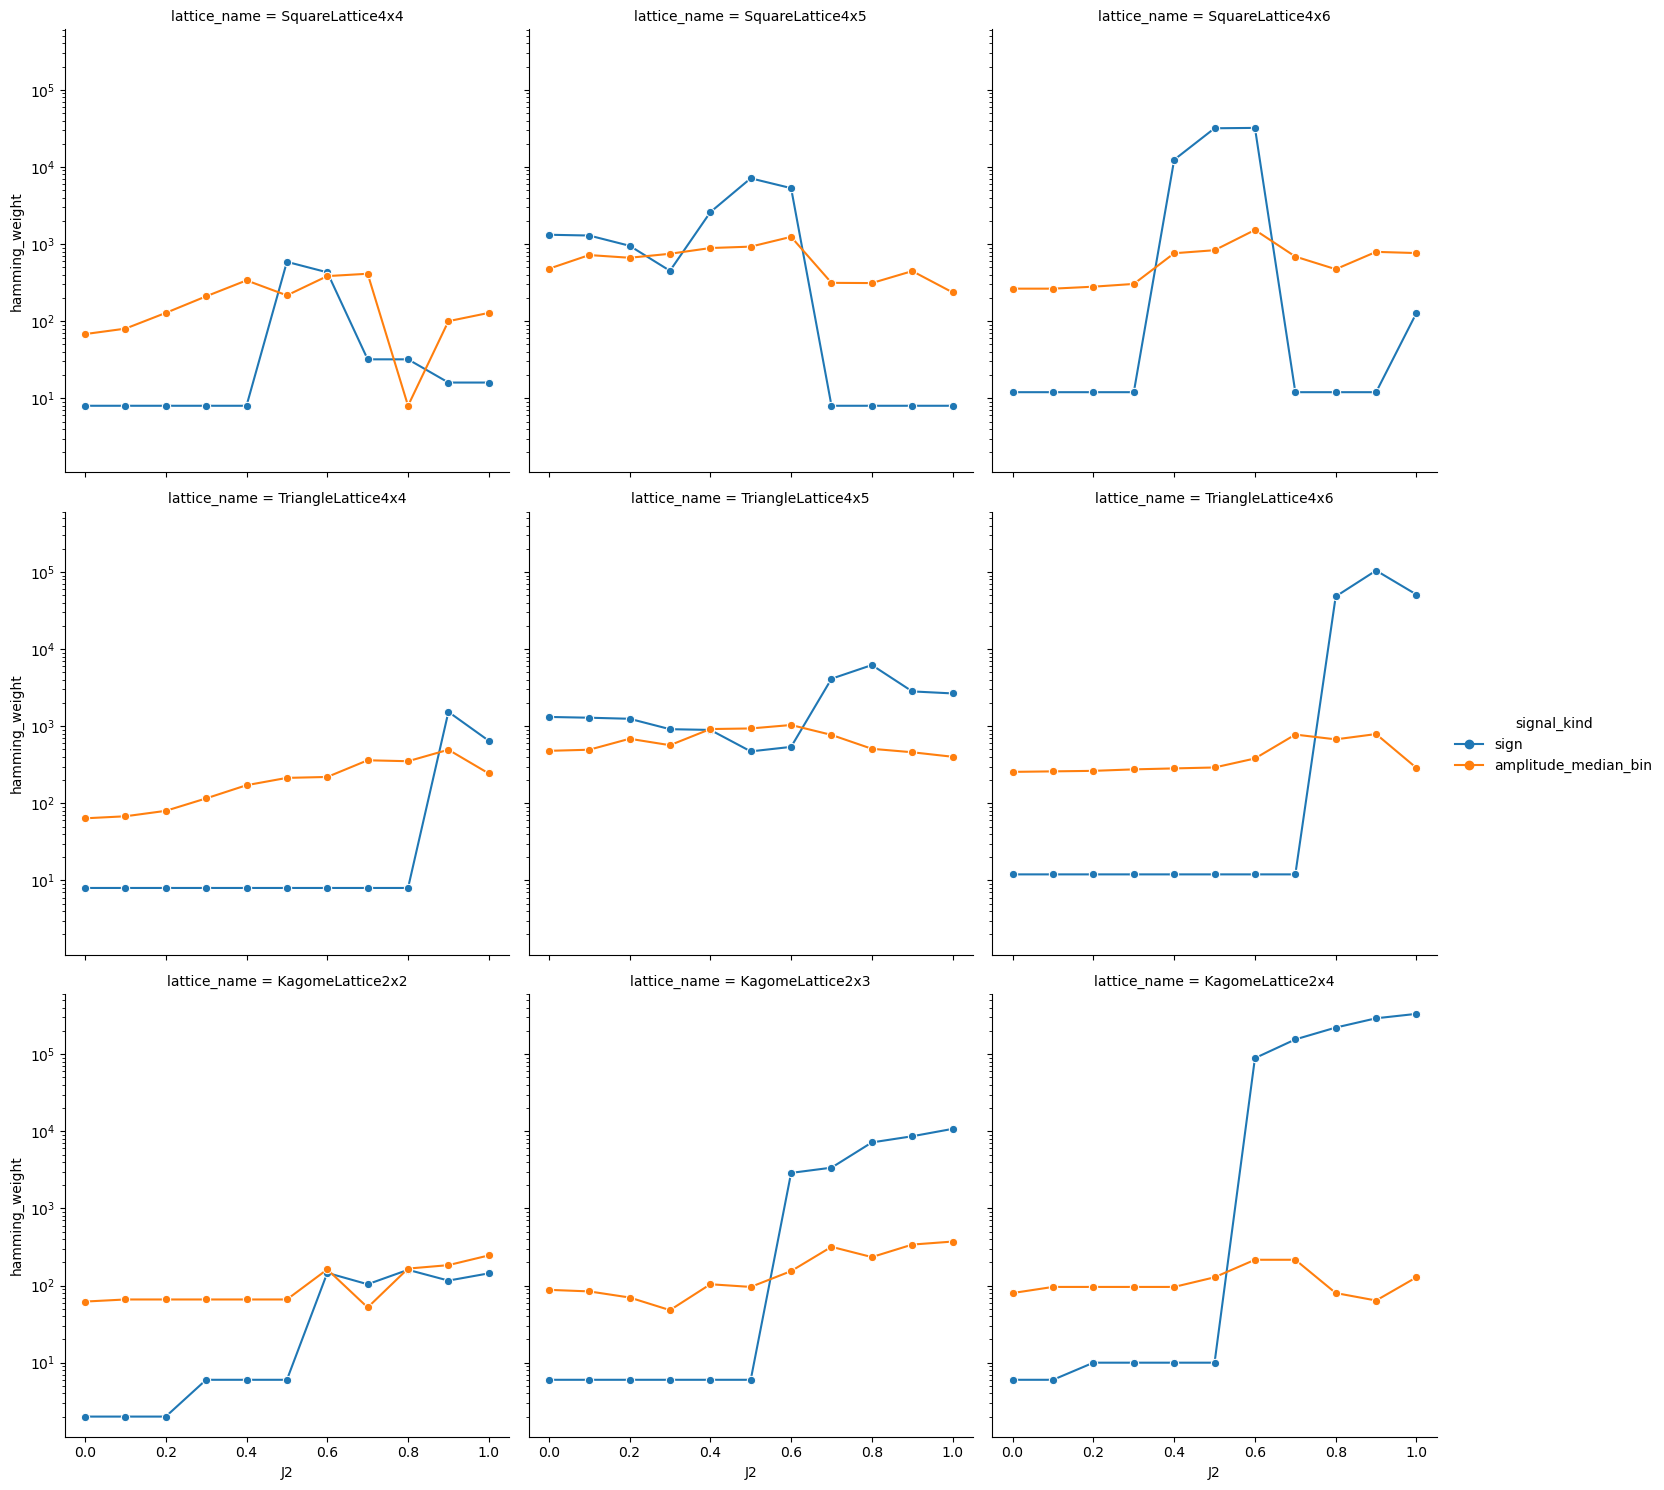

In [68]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


[None]

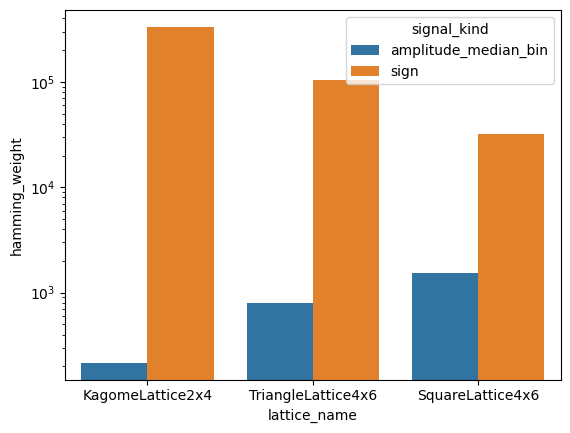

In [79]:
sns.barplot(series_df.query("number_spins == 24").reset_index().groupby(["lattice_name", "signal_kind"])[
    ["terms", "hamming_weight"]
].max().sort_values('hamming_weight').reset_index(), x='lattice_name', y='hamming_weight', hue='signal_kind').set(yscale='log')


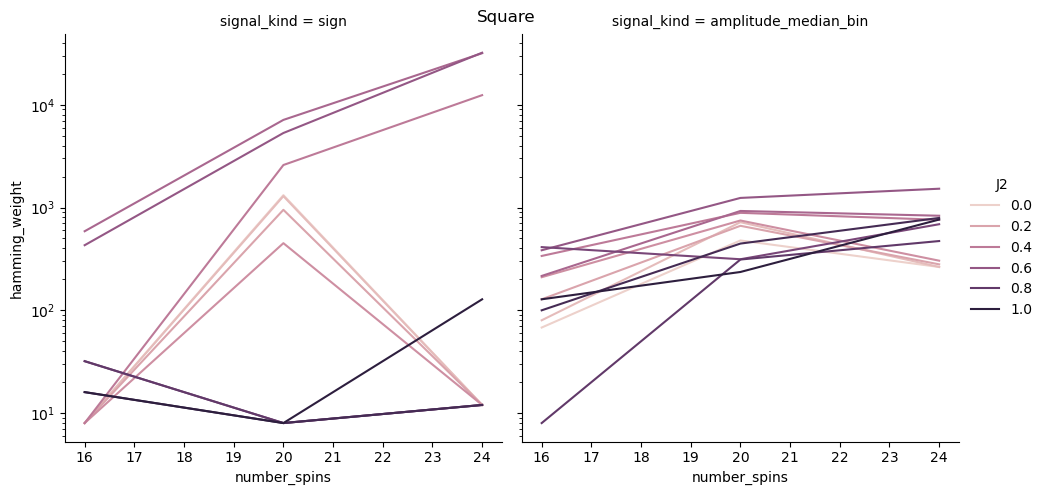

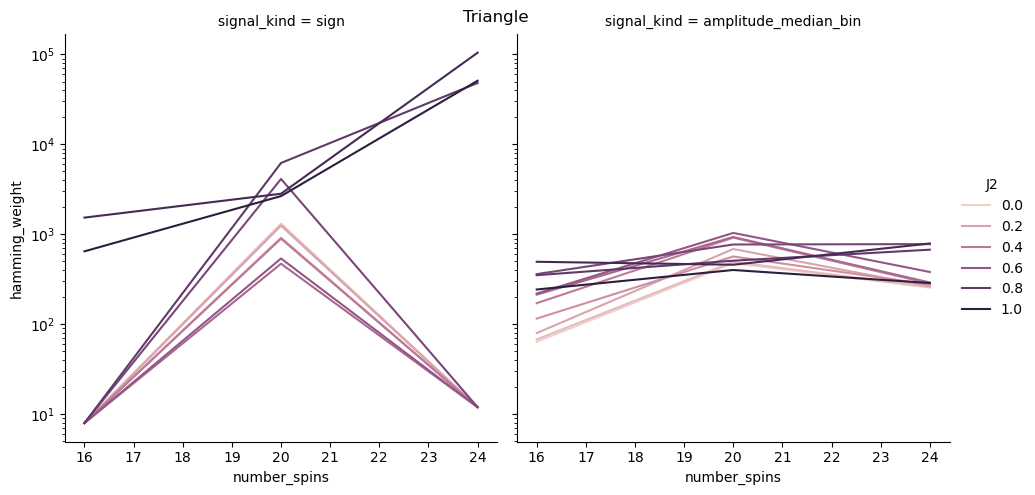

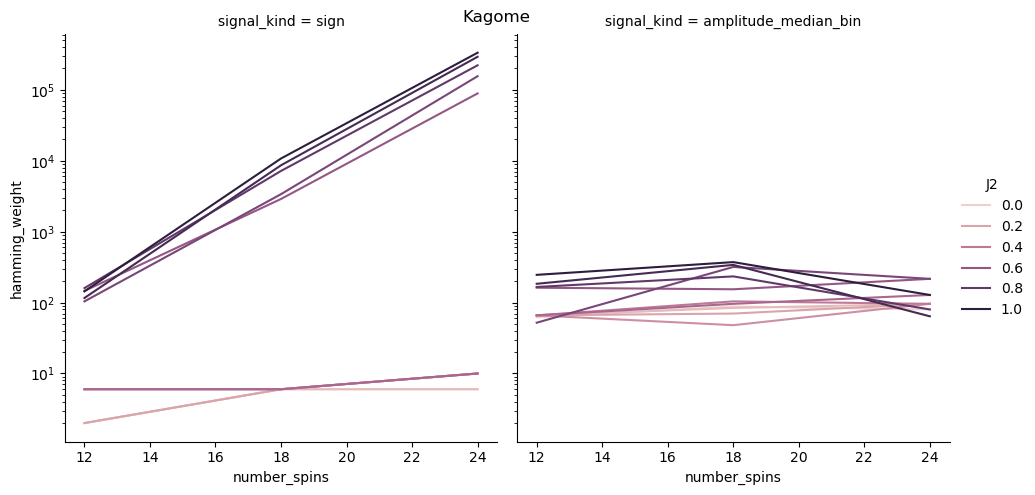

In [89]:
for lat in ['Square', 'Triangle', 'Kagome']:
    
    plot = sns.relplot(
        series_df.reset_index().query('lattice_name.str.startswith(@lat)'),
        x="number_spins",
        y="hamming_weight",
        col="signal_kind",
        hue="J2",
        kind="line",
        markers=True,
    ).set(yscale="log")
    plot.fig.suptitle(lat)


In [90]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig


In [91]:
def get_abslargest_terms(coeffs: npt.NDArray, n: int) -> tuple[npt.NDArray[np.uint64], npt.NDArray]:
    """Get the n largest terms in absolute value."""
    abs_values = np.abs(coeffs)
    indices = np.asarray(np.argpartition(abs_values, -n)[-n:], dtype=np.uint64)
    sorted_indices = indices[np.argsort(-abs_values[indices])]
    return sorted_indices, coeffs[sorted_indices]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


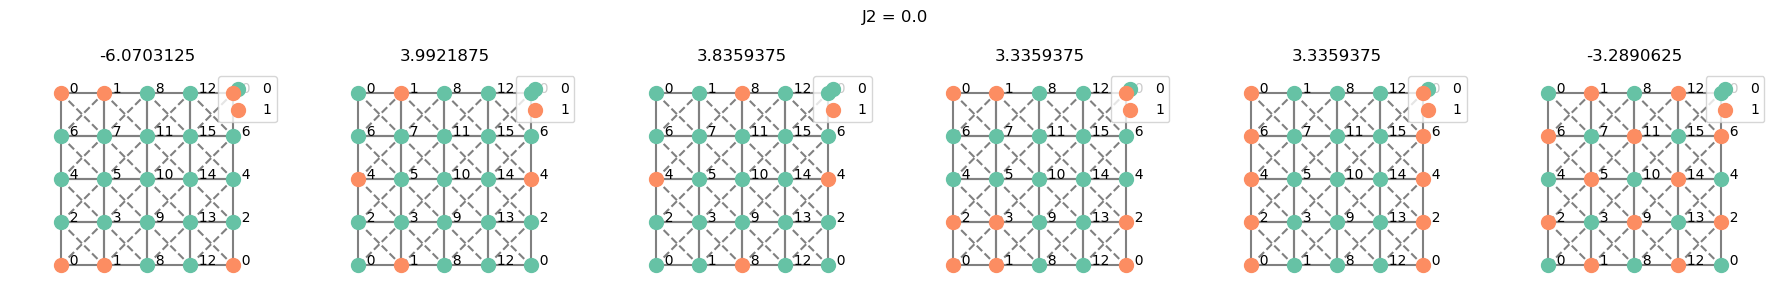

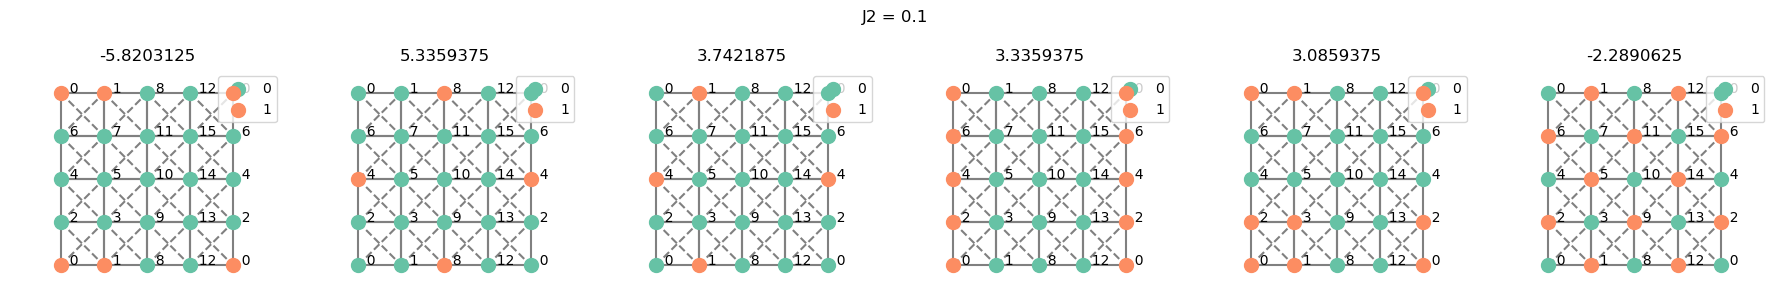

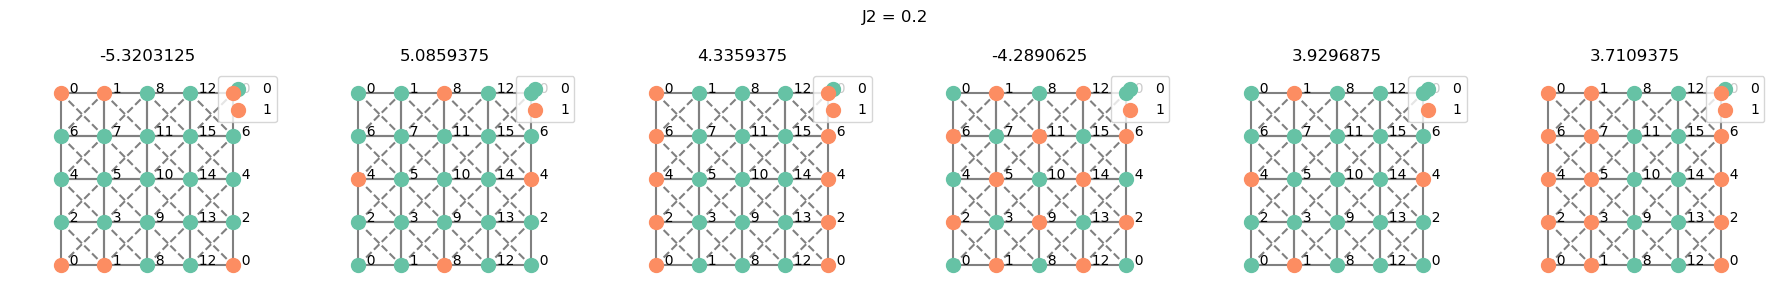

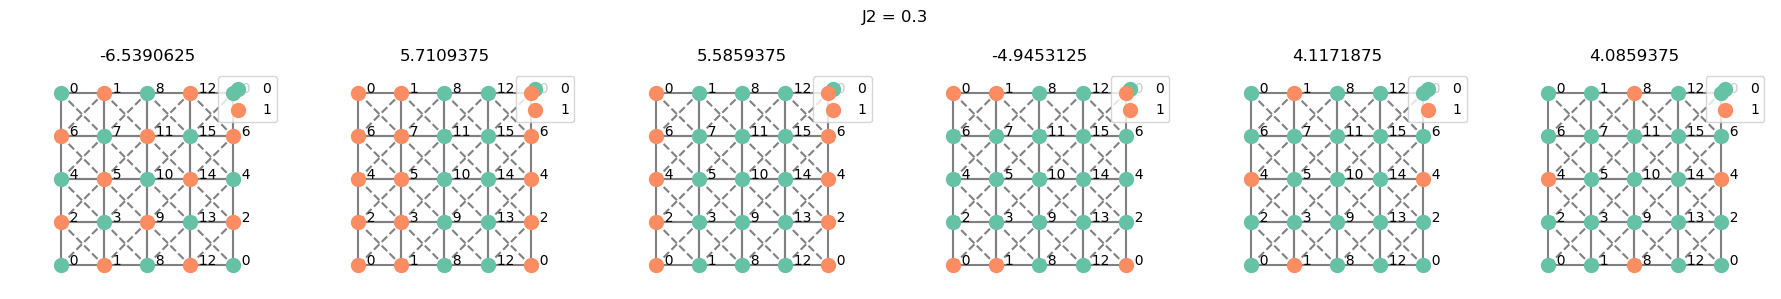

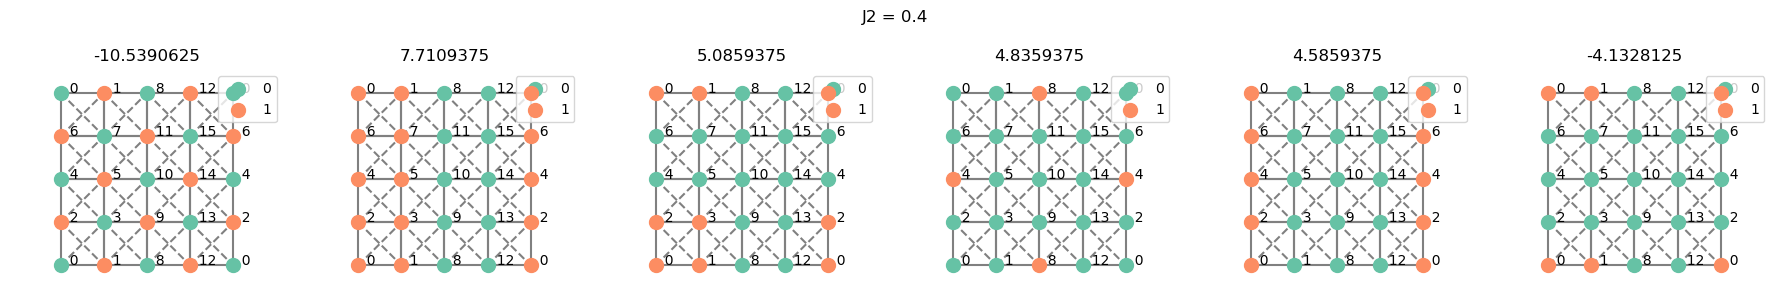

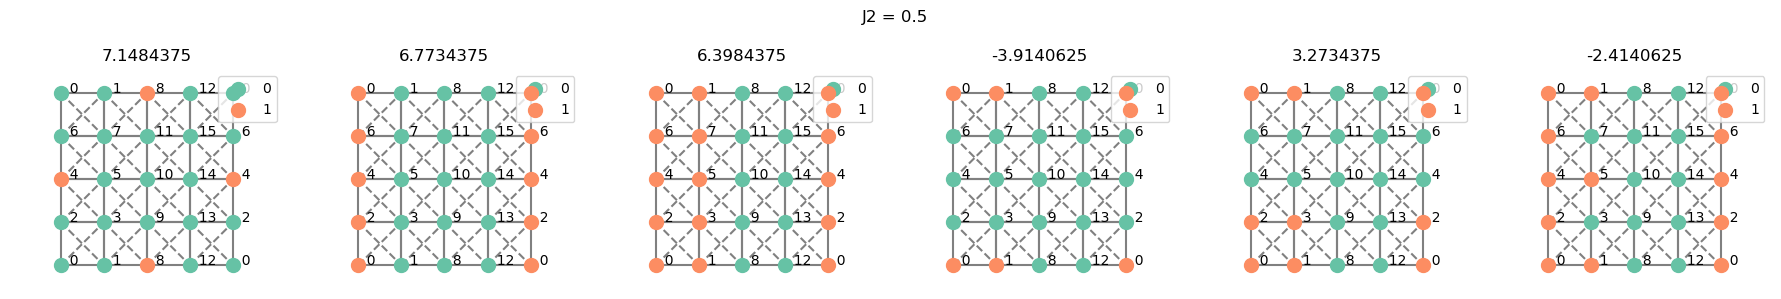

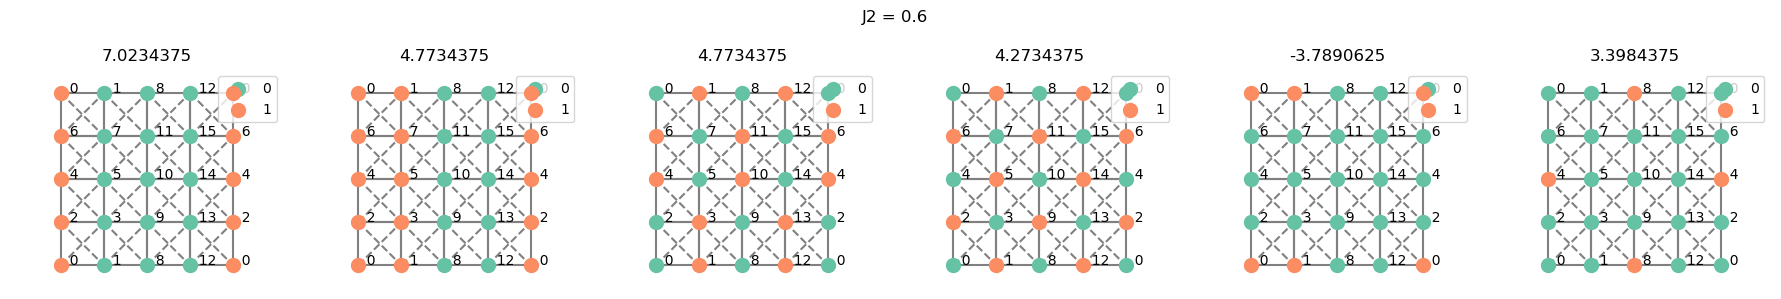

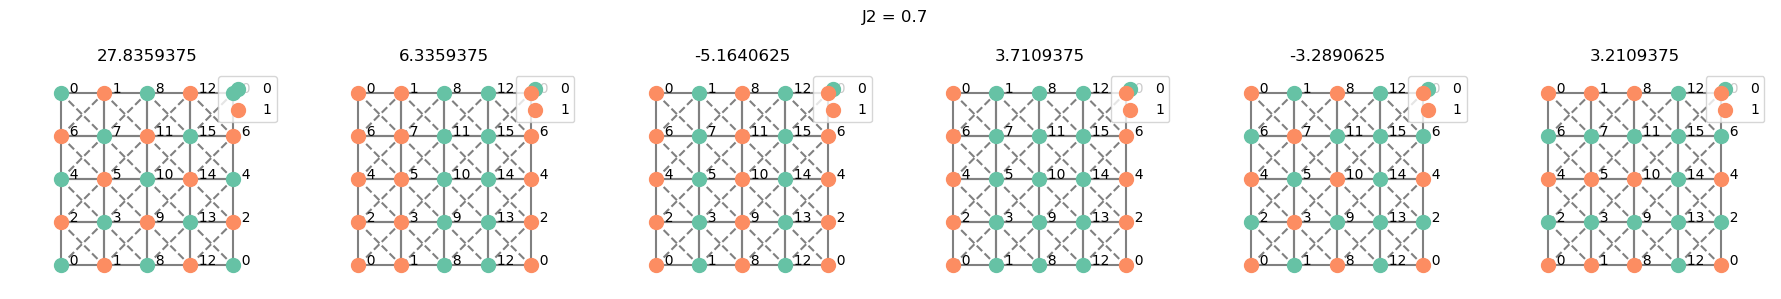

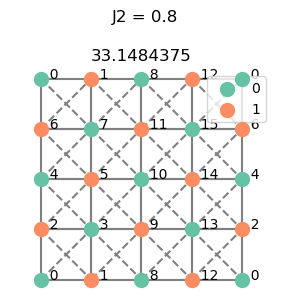

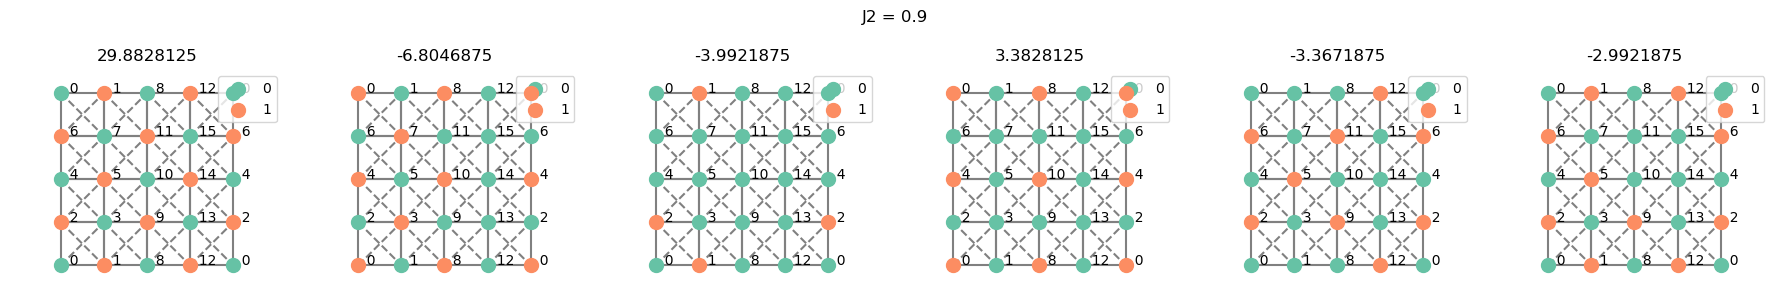

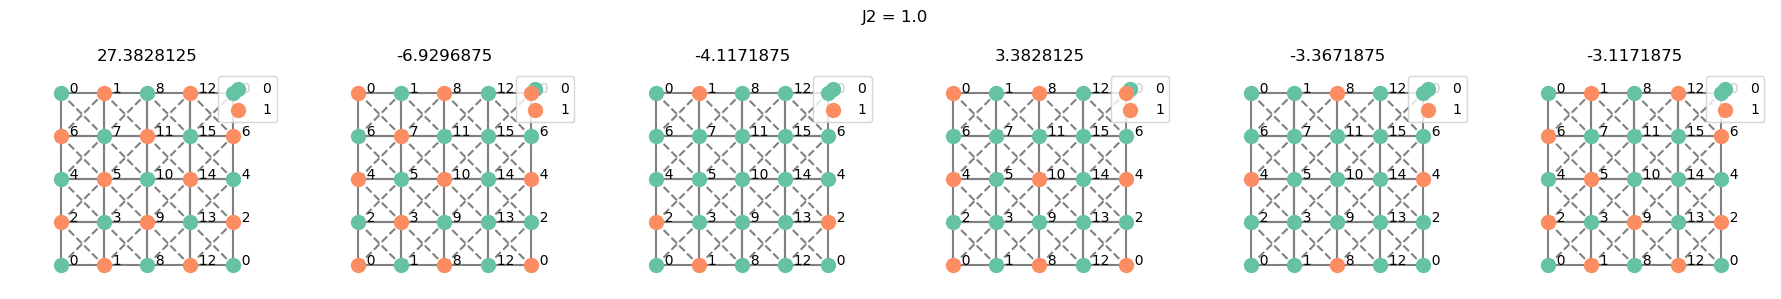

In [100]:
lattice_name = 'SquareLattice4x4'
signal = "amplitude_median_bin"
max_subsets = 6
# signal = "sign"
for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    series = row['series']
    coeffs = series.coeffs
    reprs = series.signal.lattice.get_fourier_repr().reprs
    idxs, coeffs = get_abslargest_terms(coeffs[reprs],min(max_subsets, row["terms"]))
    subsets = reprs[idxs]

    fig = plot_subsets(subsets, coeffs, row["series"].signal.lattice)
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()



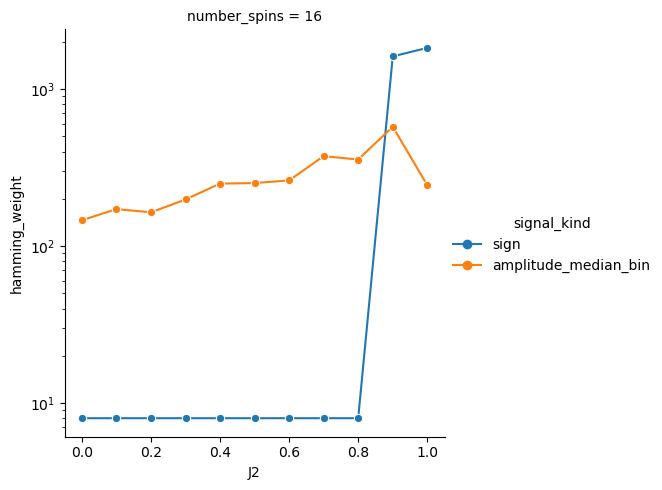

In [94]:
sns.relplot(
    series_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


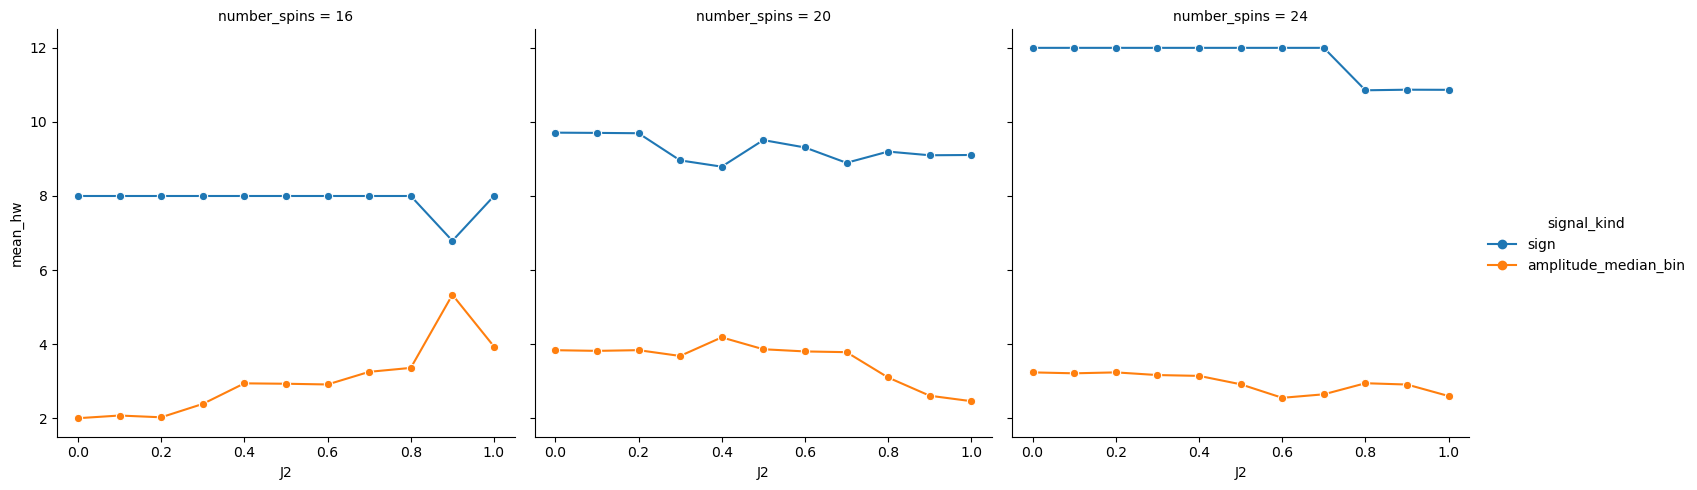

In [24]:
sns.relplot(
    series_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


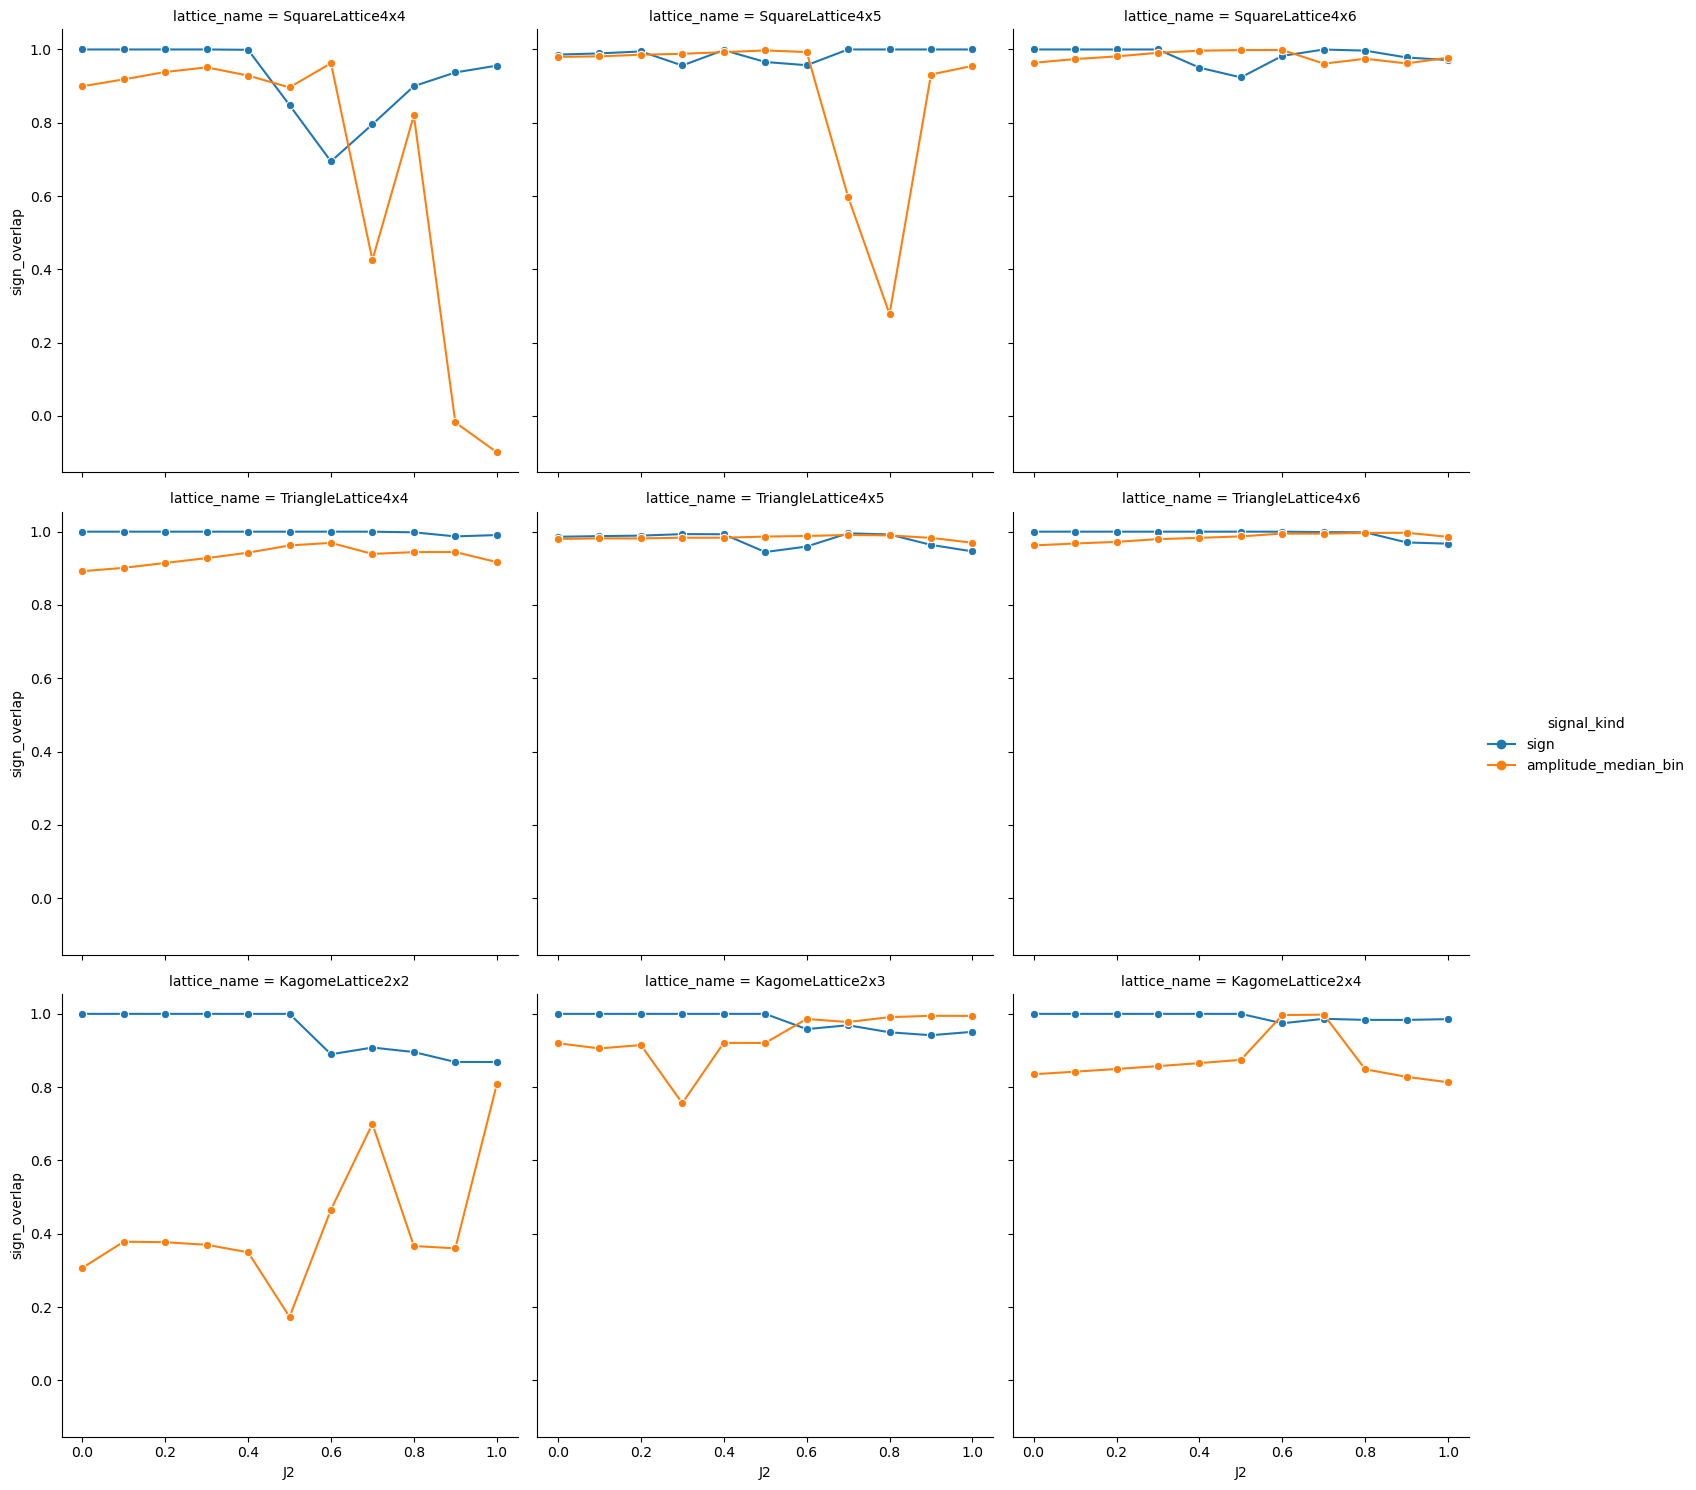

In [96]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [97]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


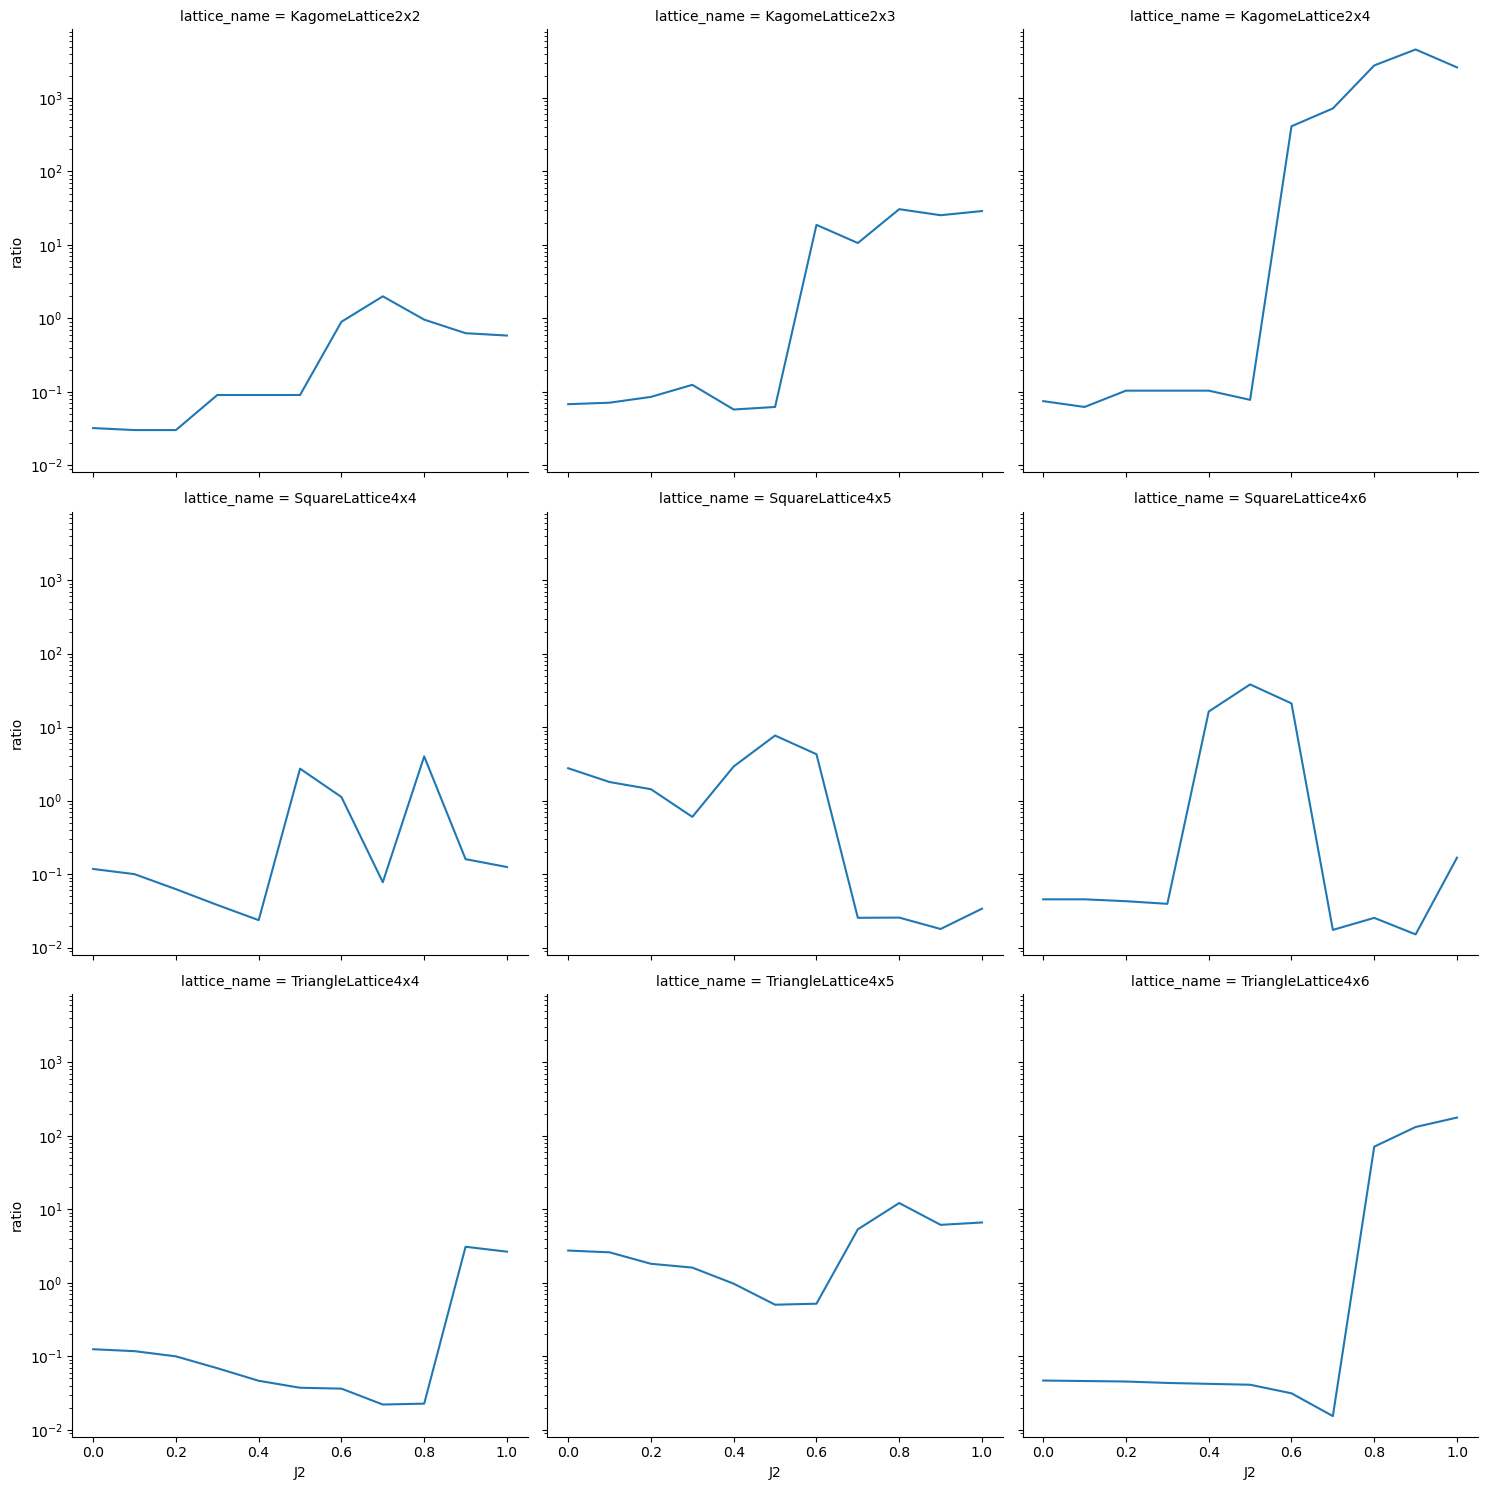

In [99]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="lattice_name", col_wrap=3,kind="line").set(yscale="log")


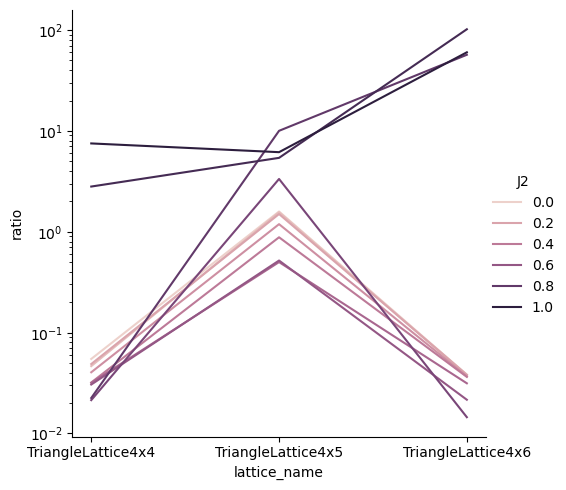

In [28]:
sns.relplot(
    complexity_ratio_df,
    x="lattice_name",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
